<a href="https://colab.research.google.com/github/sahushubham30/ZOMATO_EDA/blob/main/Zomato_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍽️ Zomato Restaurant Data — Exploratory Data Analysis
EDA project on Zomato restaurant listings, covering data cleaning,
visualizations.

**Dataset columns:** `name`, `online_order`, `book_table`, `rate`, `votes`, `approx_cost(for two people)`, `listed_in(type)`

**Contents**
1. Setup & Imports
2. Load Data
3. Data Cleaning
4. Q1 – Q6: Core Business Questions
5. Q7 – Q8: Extended Questions (New)
6. Bonus Visualizations
7. Summary of Findings


## 1. Setup & Imports

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


In [46]:

df = pd.read_csv("/content/zomato_data (1).csv")
df.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## 3. Data Cleaning

The original `rate` column looks like `4.1/5` (a string), so we convert it to a float.
We also check for missing values and duplicate rows before doing any analysis.


In [47]:
def handle_rate(value):
    """Convert '4.1/5' style strings into a float rating. Handles 'NEW' and '-' safely."""
    value = str(value).strip()
    if value in ("NEW", "-", "nan"):
        return np.nan
    value = value.split('/')[0]
    try:
        return float(value)
    except ValueError:
        return np.nan

df['rate'] = df['rate'].apply(handle_rate)
df.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [48]:
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (148, 7)

Missing values per column:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Duplicate rows: 0


In [49]:
# Drop duplicates and rows with a missing rating (can't analyze ratings without a rate value)
df = df.drop_duplicates()
df = df.dropna(subset=['rate'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


---
## Q1. What type of restaurant do the majority of customers order from?


/tmp/ipykernel_1763/1117187705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['listed_in(type)'], order=order, palette="OrRd_r")


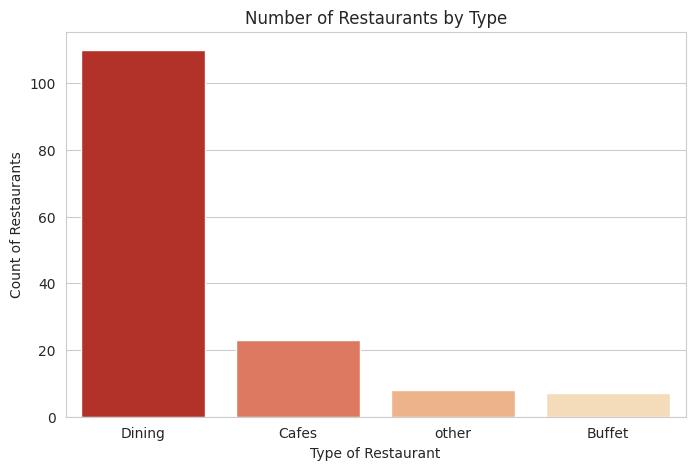

In [50]:
plt.figure(figsize=(8, 5))
order = df['listed_in(type)'].value_counts().index
sns.countplot(x=df['listed_in(type)'], order=order, palette="OrRd_r")
plt.title("Number of Restaurants by Type")
plt.xlabel("Type of Restaurant")
plt.ylabel("Count of Restaurants")
plt.show()


**Conclusion:** Majority of restaurants fall in the *Dining* category.

---
## Q2. How many votes has each type of restaurant received from customers?


In [51]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False)
result = pd.DataFrame({'votes': grouped_data})
result


,votes
listed_in(type),
Dining,20363
other,9367
Cafes,6434
Buffet,3028


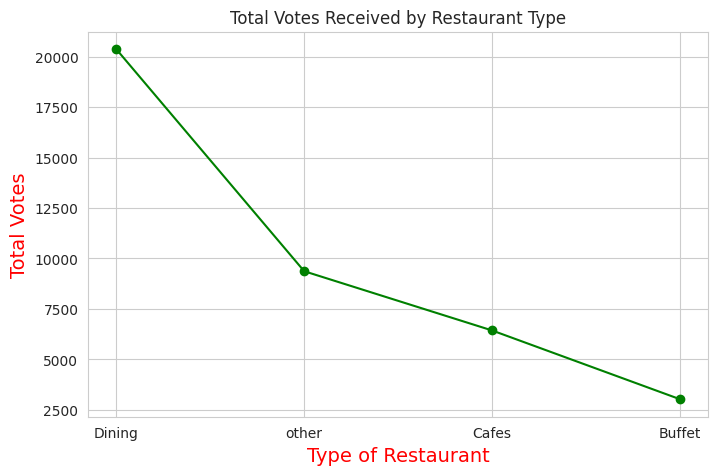

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(result.index, result['votes'], c='green', marker='o')
plt.xlabel("Type of Restaurant", color='red', size=14)
plt.ylabel("Total Votes", color='red', size=14)
plt.title("Total Votes Received by Restaurant Type")
plt.show()


**Conclusion:** Dining restaurants received the maximum votes.

---
## Q3. What ratings do the majority of restaurants have?


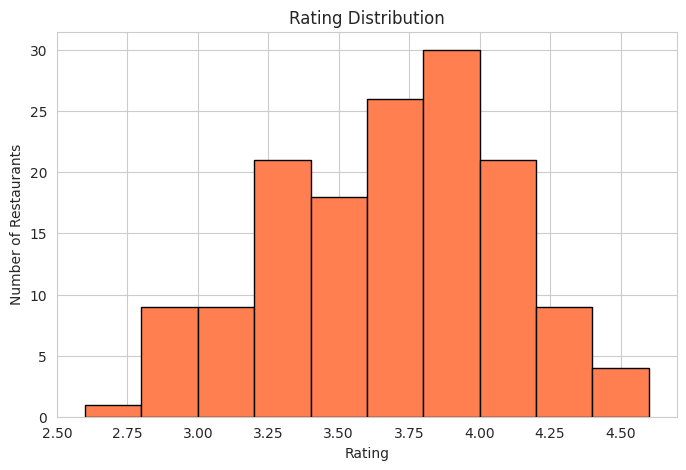

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(df['rate'], bins=10, color='coral', edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()


**Conclusion:** Most restaurants are rated between 3.5 and 4.0.

---
## Q4. What is the average spending by couples?


/tmp/ipykernel_1763/2560046328.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['approx_cost(for two people)'], palette="OrRd_r")


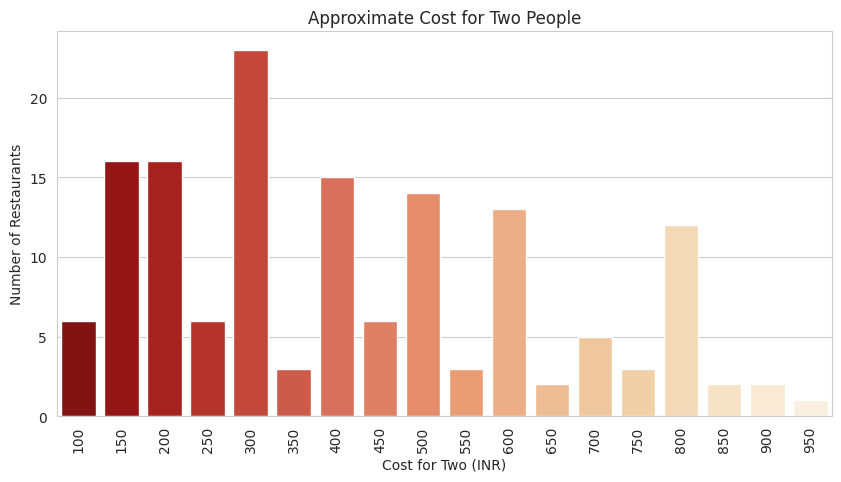

In [54]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['approx_cost(for two people)'], palette="OrRd_r")
plt.title("Approximate Cost for Two People")
plt.xlabel("Cost for Two (INR)")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=90)
plt.show()


**Conclusion:** Most couples prefer restaurants priced around ₹300 for two.

---
## Q5. Which order mode — online or offline — gets better ratings?


/tmp/ipykernel_1763/1872035995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order', y='rate', data=df, palette="OrRd")


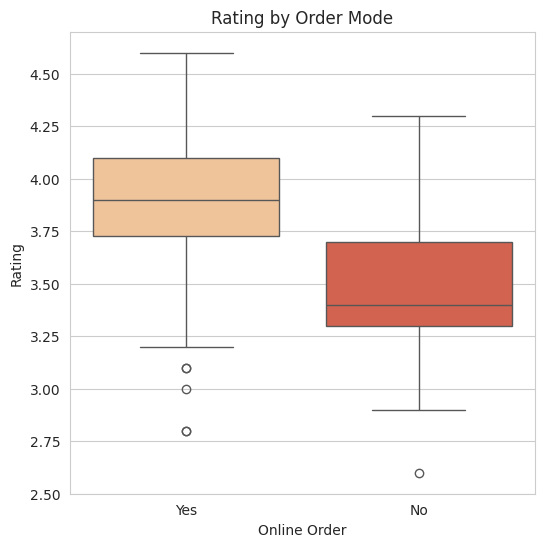

In [55]:
plt.figure(figsize=(6, 6))
sns.boxplot(x='online_order', y='rate', data=df, palette="OrRd")
plt.title("Rating by Order Mode")
plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.show()


**Conclusion:** Online orders tend to receive higher ratings than offline orders.

---
## Q6. Which restaurant type gets the most offline orders?


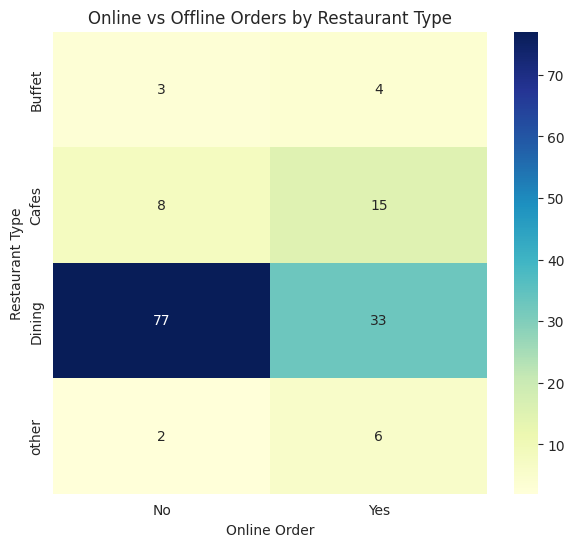

In [56]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)

plt.figure(figsize=(7, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Online vs Offline Orders by Restaurant Type")
plt.xlabel("Online Order")
plt.ylabel("Restaurant Type")
plt.show()


**Conclusion:** Dining restaurants get mostly offline orders, while Cafes get mostly online orders.

---
## Q7.  Is there a relationship between a restaurant's votes and its rating?

Do more popular (highly-voted) restaurants also tend to be rated higher?


In [57]:
correlation = df['votes'].corr(df['rate'])
print(f"Pearson correlation between votes and rating: {correlation:.3f}")


Pearson correlation between votes and rating: 0.490


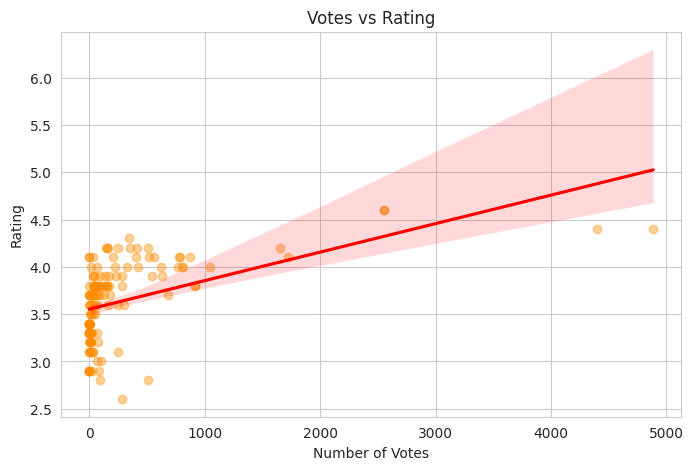

In [58]:
plt.figure(figsize=(8, 5))
sns.regplot(x='votes', y='rate', data=df, scatter_kws={'alpha': 0.4, 'color': 'darkorange'},
            line_kws={'color': 'red'})
plt.title("Votes vs Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")
plt.show()


**Conclusion:** There is a positive correlation between votes and rating — restaurants with
more votes (i.e. more popular / more reviewed) tend to have somewhat higher ratings, though the
relationship is moderate rather than very strong.

---
## Q8.  Which restaurants are the highest rated among the most popular ones?

Restaurants can get a perfect-looking rating from just a handful of votes, which isn't very
trustworthy. So we only consider restaurants with a reasonable number of votes (above the
median) before ranking them by rating.


In [59]:
min_votes = df['votes'].median()
reliable = df[df['votes'] >= min_votes]

top_10 = reliable.sort_values(by=['rate', 'votes'], ascending=[False, False]).head(10)
top_10[['name', 'listed_in(type)', 'rate', 'votes', 'approx_cost(for two people)']]


,name,listed_in(type),rate,votes,approx_cost(for two people)
7,Onesta,Cafes,4.6,2556,600
44,Onesta,other,4.6,2556,600
38,Empire Restaurant,other,4.4,4884,750
86,Meghana Foods,Dining,4.4,4401,600
52,Corner House Ice Cream,Dining,4.3,345,400
37,Szechuan Dragon,Dining,4.2,1647,600
9,Smacznego,Cafes,4.2,504,550
34,Faasos,other,4.2,415,500
57,Wamama,other,4.2,354,800
60,Peppy Peppers,other,4.2,244,800


/tmp/ipykernel_1763/1245813870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rate', y='name', data=top_10, palette="OrRd_r")


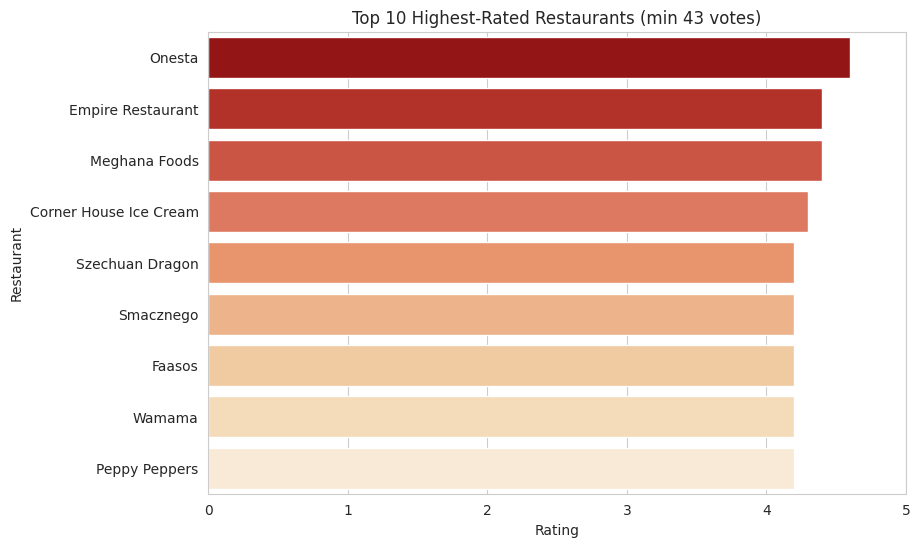

In [60]:
plt.figure(figsize=(9, 6))
sns.barplot(x='rate', y='name', data=top_10, palette="OrRd_r")
plt.title(f"Top 10 Highest-Rated Restaurants (min {int(min_votes)} votes)")
plt.xlabel("Rating")
plt.ylabel("Restaurant")
plt.xlim(0, 5)
plt.show()


**Conclusion:** Even after filtering for restaurants with a meaningful number of votes, a clear set of standout, consistently highly-rated restaurants emerges.

---



###  Scatter Plot: Cost for Two vs Rating

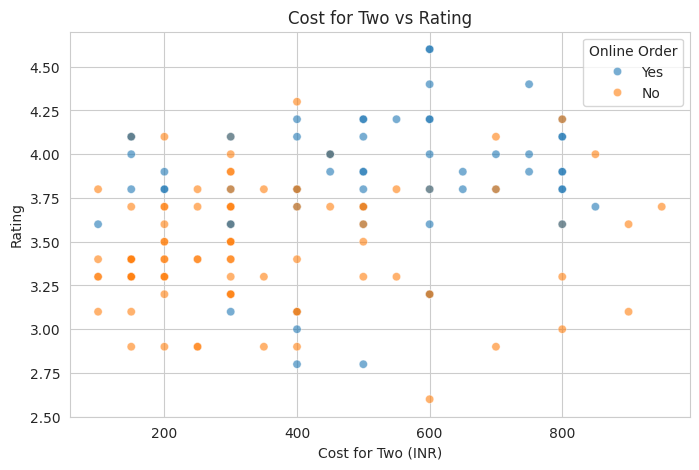

In [61]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='approx_cost(for two people)', y='rate', hue='online_order', data=df, alpha=0.6)
plt.title("Cost for Two vs Rating")
plt.xlabel("Cost for Two (INR)")
plt.ylabel("Rating")
plt.legend(title="Online Order")
plt.show()


**Observation:** Higher-cost restaurants tend to cluster at slightly higher ratings, though plenty of affordable restaurants are also highly rated.

###  Pie Chart: Share of Restaurant Types

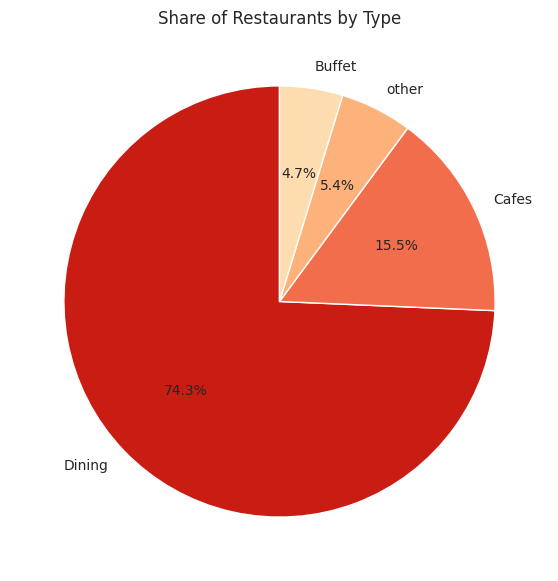

In [62]:
type_counts = df['listed_in(type)'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette("OrRd_r", len(type_counts)), startangle=90)
plt.title("Share of Restaurants by Type")
plt.show()


**Observation:** Dining makes up the largest single share of restaurants, consistent with the count plot in Q1.